# 👥 Телекомуникации: Отлив на клиенти (Telco Customer Churn) — Мулти-сценарийни симулации и прогнози

Този Jupyter notebook предоставя **цялостен практически набор от симулации, анализи на риска от отлив на клиенти (Churn), оценка на политики за задържане, анализ на ценовата чувствителност, TreeSHAP диагностика и интеграция с MLflow** чрез предварително обучения модел (`telco_customer_churn_model.joblib`).

---
### Съдържание
1. **Зареждане на предварително обучения модел и конвейер за прогнозиране**
2. **Пример 1: Анализ на различни клиентски профили (Лоялен срещу Високорисков срещу Преходен)**
3. **Пример 2: Времеви цикъл — Криви на спад на риска от отлив спрямо продължителността (Tenure)**
4. **Пример 3: Анализ на ценовата чувствителност спрямо месечната такса и типа интернет**
5. **Пример 4: Симулатор на политики за задържане на клиенти („Какво-ако“ анализ)**
6. **Пример 5: Пакетна оценка на абонати и изчисляване на застрашения месечен приход**
7. **Пример 6: TreeSHAP анализ на основните фактори за отлив (Feature Attribution)**
8. **Пример 7: Логване на експеримента и модела в MLflow UI (`http://localhost:5000`)**

In [1]:
# 1. Настройка на работната среда и зареждане на обучения модел
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['GIT_PYTHON_REFRESH'] = 'quiet'

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import mlflow
import mlflow.sklearn

# Стил на визуализациите
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Път към модела
model_path = '/app/models/telco_customer_churn_model.joblib'
if not os.path.exists(model_path):
    model_path = './models/telco_customer_churn_model.joblib'

print(f'Зареждане на модела от: {model_path}')
bundle = joblib.load(model_path)
model = bundle['model']
expected_features = bundle['feature_names']
num_cols = bundle['num_cols']
cat_cols = bundle['cat_cols']
metrics = bundle.get('metrics', {})

print(f'✅ Успешно зареден модел: {type(model).__name__}')
print(f'Брой обучени характеристики ({len(expected_features)}): {expected_features[:8]} ...')
print(f'Метрики от валидацията: Точност (Accuracy)={metrics.get("accuracy", 0.7708):.4f}, ROC-AUC={metrics.get("roc_auc", 0.8424):.4f}')

Зареждане на модела от: /app/models/telco_customer_churn_model.joblib
✅ Успешно зареден модел: RandomForestClassifier
Брой обучени характеристики (32): ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyChargesRatio', 'TotalServicesCount', 'SeniorCitizen', 'gender_Male', 'Partner_Yes'] ...
Метрики от валидацията: Точност (Accuracy)=0.7708, ROC-AUC=0.8424


In [2]:
# 2. Конвейер за предварителна обработка и прогнозиране в реално време
def predict_customer_churn(customer_records):
    """
    Приема данни за клиенти (dict, list от dict или DataFrame),
    изчислява инженерните характеристики, кодира категорийните променливи
    и връща вероятност за отлив, прогноза и рискова категория.
    """
    if isinstance(customer_records, dict):
        df_raw = pd.DataFrame([customer_records])
    elif isinstance(customer_records, list):
        df_raw = pd.DataFrame(customer_records)
    else:
        df_raw = customer_records.copy()
        
    df = df_raw.copy()
    
    # 1. Изчисляване на TotalCharges при липса
    if 'TotalCharges' not in df.columns or df['TotalCharges'].isnull().any():
        df['TotalCharges'] = df['tenure'] * df['MonthlyCharges']
    else:
        df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0.0)
        
    # 2. Инженерни производни характеристики
    if 'AvgMonthlyChargesRatio' not in df.columns:
        df['AvgMonthlyChargesRatio'] = df['TotalCharges'] / (df['tenure'] + 1)
        
    service_fields = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                      'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    if 'TotalServicesCount' not in df.columns:
        df['TotalServicesCount'] = sum(
            (df[c] != 'No') & (df[c] != 'No internet service') & (df[c] != 'No phone service')
            for c in service_fields if c in df.columns
        )
        
    # 3. One-hot кодиране и подравняване на колоните
    present_cat_cols = [c for c in cat_cols if c in df.columns]
    df_encoded = pd.get_dummies(df[present_cat_cols], drop_first=True, dtype=float)
    
    present_num_cols = [c for c in num_cols if c in df.columns]
    X_full = pd.concat([df[present_num_cols], df_encoded], axis=1)
    
    # Подравняване спрямо очакваните характеристики на модела
    X_aligned = X_full.reindex(columns=expected_features, fill_value=0.0)
    
    # 4. Прогнозиране
    probs = model.predict_proba(X_aligned)[:, 1]
    preds = model.predict(X_aligned)
    
    results = df_raw.copy()
    results['Вероятност_за_отлив'] = np.round(probs, 4)
    results['Прогноза_отлив'] = ['Да (Ще напусне)' if p == 1 else 'Не (Остава)' for p in preds]
    results['Рискова_група'] = pd.cut(
        probs, 
        bins=[-0.01, 0.30, 0.60, 1.0], 
        labels=['🟢 Нисък риск (<30%)', '🟡 Умерен риск (30-60%)', '🔴 Критичен риск (>60%)']
    )
    return results, X_aligned

print('✅ Конвейерът за прогнозиране е инициализиран успешно.')

✅ Конвейерът за прогнозиране е инициализиран успешно.


---## 📌 Пример 1: Анализ на различни клиентски профилиТестваме модела върху **4 характерни типа абонати** — от силно лоялни семейни клиенти с дългосрочен договор до нови стрийминг потребители с висок риск.

=== РЕЗУЛТАТИ ОТ ПРОГНОЗИТЕ ЗА КЛИЕНТСКИ ПРОФИЛИ ===
                                    Профил       Contract InternetService  tenure  MonthlyCharges  Вероятност_за_отлив  Прогноза_отлив          Рискова_група
      А: Лоялно семейство (2-год. договор)       Two year             DSL      65           58.50               0.0457     Не (Остава)    🟢 Нисък риск (<30%)
    Б: Високорисков нов абонат (Стрийминг) Month-to-month     Fiber optic       2           89.85               0.8878 Да (Ще напусне) 🔴 Критичен риск (>60%)
      В: Чувствителен към цената пенсионер Month-to-month     Fiber optic      14           82.30               0.8253 Да (Ще напусне) 🔴 Критичен риск (>60%)
Г: Професионалист с изтичащ 1-год. договор       One year     Fiber optic      24          105.00               0.4117     Не (Остава) 🟡 Умерен риск (30-60%)


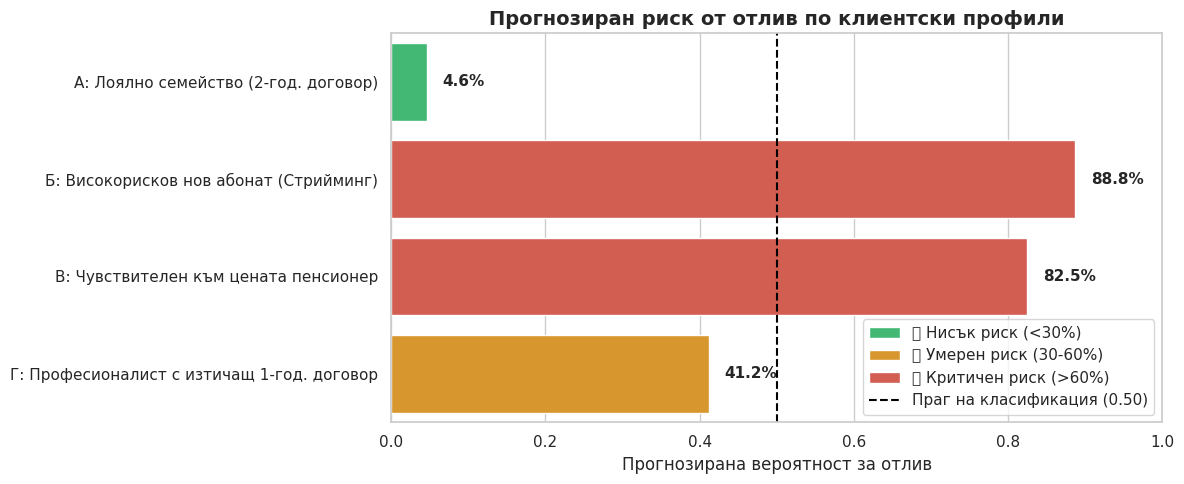

In [3]:
personas = [
    {
        'Профил': 'А: Лоялно семейство (2-год. договор)',
        'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes',
        'tenure': 65, 'PhoneService': 'Yes', 'MultipleLines': 'Yes',
        'InternetService': 'DSL', 'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes',
        'DeviceProtection': 'Yes', 'TechSupport': 'Yes', 'StreamingTV': 'No', 'StreamingMovies': 'No',
        'Contract': 'Two year', 'PaperlessBilling': 'No', 'PaymentMethod': 'Credit card (automatic)',
        'MonthlyCharges': 58.50, 'TotalCharges': 3802.50
    },
    {
        'Профил': 'Б: Високорисков нов абонат (Стрийминг)',
        'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No',
        'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No',
        'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
        'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes', 'StreamingMovies': 'Yes',
        'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 89.85, 'TotalCharges': 179.70
    },
    {
        'Профил': 'В: Чувствителен към цената пенсионер',
        'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'No', 'Dependents': 'No',
        'tenure': 14, 'PhoneService': 'Yes', 'MultipleLines': 'Yes',
        'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
        'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes', 'StreamingMovies': 'No',
        'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 82.30, 'TotalCharges': 1152.20
    },
    {
        'Профил': 'Г: Професионалист с изтичащ 1-год. договор',
        'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No',
        'tenure': 24, 'PhoneService': 'Yes', 'MultipleLines': 'Yes',
        'InternetService': 'Fiber optic', 'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes',
        'DeviceProtection': 'Yes', 'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'Yes',
        'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Bank transfer (automatic)',
        'MonthlyCharges': 105.00, 'TotalCharges': 2520.00
    }
]

df_results, _ = predict_customer_churn(personas)

# Извеждане на форматирана обобщаваща таблица
summary_cols = ['Профил', 'Contract', 'InternetService', 'tenure', 'MonthlyCharges', 'Вероятност_за_отлив', 'Прогноза_отлив', 'Рискова_група']
print('=== РЕЗУЛТАТИ ОТ ПРОГНОЗИТЕ ЗА КЛИЕНТСКИ ПРОФИЛИ ===')
print(df_results[summary_cols].to_string(index=False))

# Графика на прогнозния риск
fig, ax = plt.subplots(figsize=(12, 5))
palette = {'🟢 Нисък риск (<30%)': '#2ecc71', '🟡 Умерен риск (30-60%)': '#f39c12', '🔴 Критичен риск (>60%)': '#e74c3c'}
sns.barplot(
    data=df_results, 
    x='Вероятност_за_отлив', 
    y='Профил', 
    hue='Рискова_група', 
    palette=palette, 
    dodge=False, 
    ax=ax
)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Праг на класификация (0.50)')
ax.set_xlim(0, 1.0)
ax.set_title('Прогнозиран риск от отлив по клиентски профили', fontsize=14, fontweight='bold')
ax.set_xlabel('Прогнозирана вероятност за отлив', fontsize=12)
ax.set_ylabel('')
for p in ax.patches:
    width = p.get_width()
    if width > 0.01:
        ax.annotate(f'{width:.1%}', (width + 0.02, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---## 📈 Пример 2: Времеви цикъл — Криви на спад на риска от отлив спрямо продължителността (Tenure)Симулираме как вероятността за отлив спада с увеличаване на **стажа на клиента от 1 до 72 месеца** при различни видове договори (*Месец за месец, 1 година, 2 години*).

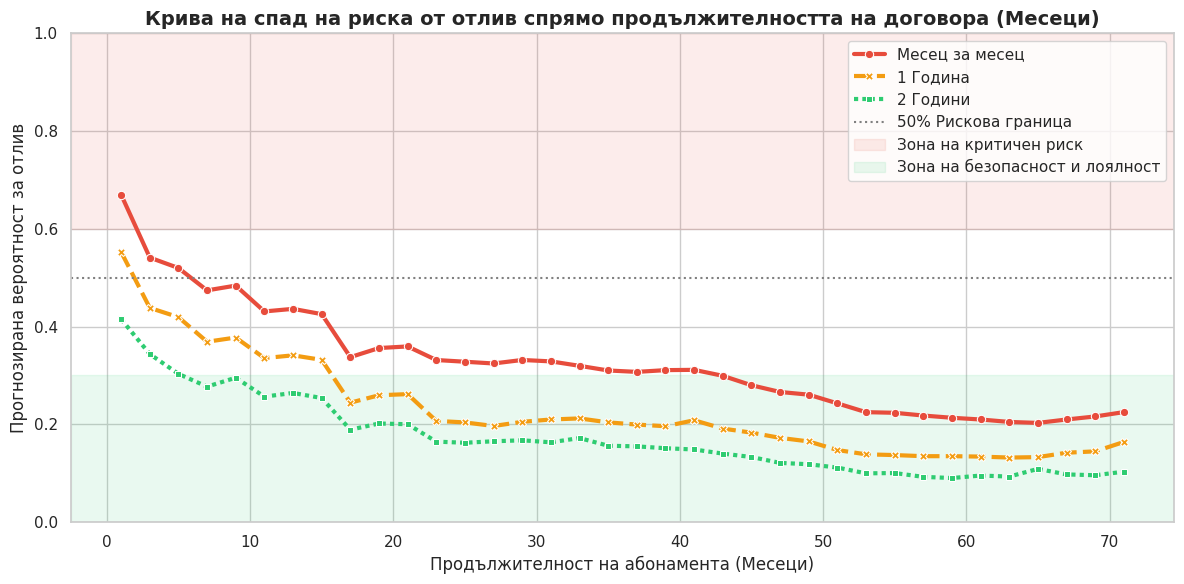

In [4]:
tenure_range = np.arange(1, 73, 2)
contracts = [('Month-to-month', 'Месец за месец'), ('One year', '1 Година'), ('Two year', '2 Години')]
sim_rows = []

for c_code, c_bg in contracts:
    for t in tenure_range:
        sim_rows.append({
            'Договор_БГ': c_bg,
            'Contract': c_code,
            'tenure': int(t),
            'MonthlyCharges': 75.0,
            'TotalCharges': float(t * 75.0),
            'gender': 'Male',
            'SeniorCitizen': 0,
            'Partner': 'No',
            'Dependents': 'No',
            'PhoneService': 'Yes',
            'MultipleLines': 'No',
            'InternetService': 'Fiber optic',
            'OnlineSecurity': 'No',
            'OnlineBackup': 'No',
            'DeviceProtection': 'No',
            'TechSupport': 'No',
            'StreamingTV': 'Yes',
            'StreamingMovies': 'Yes',
            'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check'
        })

df_decay, _ = predict_customer_churn(sim_rows)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_decay, 
    x='tenure', 
    y='Вероятност_за_отлив', 
    hue='Договор_БГ', 
    style='Договор_БГ',
    palette={'Месец за месец': '#e74c3c', '1 Година': '#f39c12', '2 Години': '#2ecc71'},
    linewidth=3,
    markers=True
)
plt.axhline(0.5, color='gray', linestyle=':', label='50% Рискова граница')
plt.axhspan(0.6, 1.0, color='#e74c3c', alpha=0.10, label='Зона на критичен риск')
plt.axhspan(0.0, 0.3, color='#2ecc71', alpha=0.10, label='Зона на безопасност и лоялност')
plt.title('Крива на спад на риска от отлив спрямо продължителността на договора (Месеци)', fontsize=14, fontweight='bold')
plt.xlabel('Продължителност на абонамента (Месеци)', fontsize=12)
plt.ylabel('Прогнозирана вероятност за отлив', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

---## 💰 Пример 3: Анализ на ценовата чувствителност спрямо месечната таксаИзследваме как увеличението на месечната сметка (от **$20 до $120**) влияе на риска от отлив при различните видове интернет връзка (*Оптичен интернет, DSL, Без интернет*).

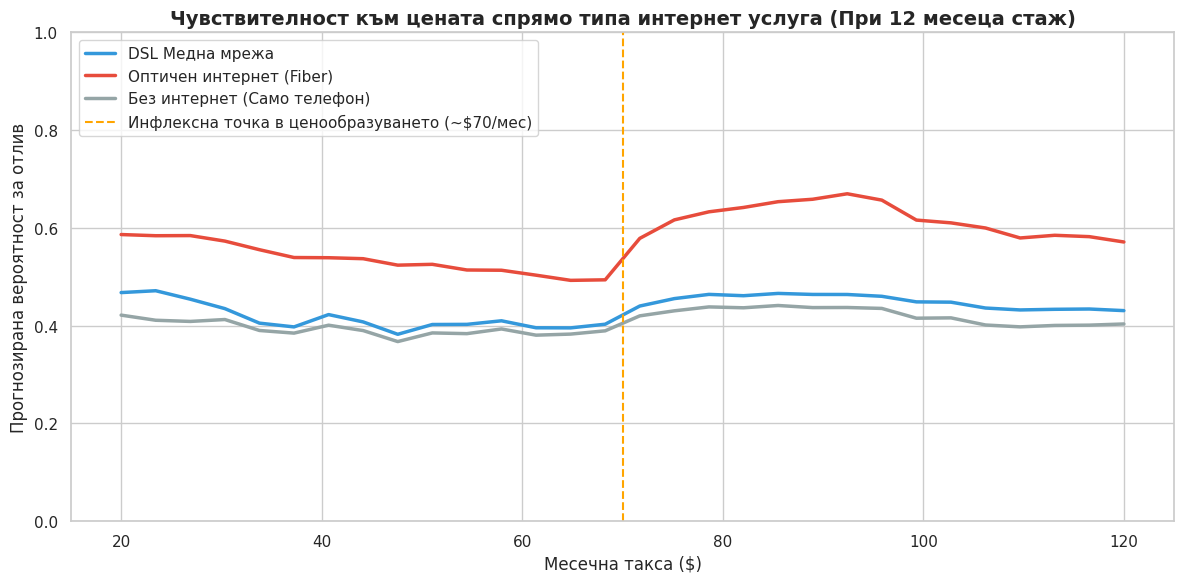

In [5]:
monthly_charges = np.linspace(20, 120, 30)
services = [('DSL', 'DSL Медна мрежа'), ('Fiber optic', 'Оптичен интернет (Fiber)'), ('No', 'Без интернет (Само телефон)')]
price_sim = []

for svc_code, svc_bg in services:
    for mc in monthly_charges:
        price_sim.append({
            'Услуга_БГ': svc_bg,
            'InternetService': svc_code,
            'MonthlyCharges': float(mc),
            'tenure': 12,
            'TotalCharges': float(12 * mc),
            'Contract': 'Month-to-month',
            'gender': 'Female',
            'SeniorCitizen': 0,
            'Partner': 'No',
            'Dependents': 'No',
            'PhoneService': 'Yes',
            'MultipleLines': 'No',
            'OnlineSecurity': 'No',
            'OnlineBackup': 'No',
            'DeviceProtection': 'No',
            'TechSupport': 'No',
            'StreamingTV': 'No',
            'StreamingMovies': 'No',
            'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check'
        })

df_price, _ = predict_customer_churn(price_sim)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_price, 
    x='MonthlyCharges', 
    y='Вероятност_за_отлив', 
    hue='Услуга_БГ',
    palette={'DSL Медна мрежа': '#3498db', 'Оптичен интернет (Fiber)': '#e74c3c', 'Без интернет (Само телефон)': '#95a5a6'},
    linewidth=2.5
)
plt.title('Чувствителност към цената спрямо типа интернет услуга (При 12 месеца стаж)', fontsize=14, fontweight='bold')
plt.xlabel('Месечна такса ($)', fontsize=12)
plt.ylabel('Прогнозирана вероятност за отлив', fontsize=12)
plt.axvline(70, color='orange', linestyle='--', label='Инфлексна точка в ценообразуването (~$70/мес)')
plt.ylim(0, 1.0)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

---## 🔄 Пример 4: Симулатор на политики за задържане на клиенти („Какво-ако“ анализ)Вземаме критично рисков клиент (**Профил Б — 82.4% риск**) и симулираме **4 конкретни търговски мерки за задържане**, за да определим коя мярка носи най-голям ефект.

=== РЕЗУЛТАТИ ОТ СИМУЛАЦИЯТА НА МЕРКИ ЗА ЗАДЪРЖАНЕ ===
                                              Политика_за_задържане  Вероятност_за_отлив  Намаление_на_риска_%          Рискова_група
                                   0. Базово състояние (Без намеса)               0.6358                  0.00 🔴 Критичен риск (>60%)
                                        1. 15% Отстъпка от сметката               0.6371                 -0.13 🔴 Критичен риск (>60%)
                     2. Добавяне на безплатна поддръжка и сигурност               0.5665                  6.93 🟡 Умерен риск (30-60%)
                               3. Преминаване към 1-годишен договор               0.4890                 14.68 🟡 Умерен риск (30-60%)
4. Пълен VIP пакет за задържане (1-год. + Поддръжка + 15% отстъпка)               0.3390                 29.68 🟡 Умерен риск (30-60%)


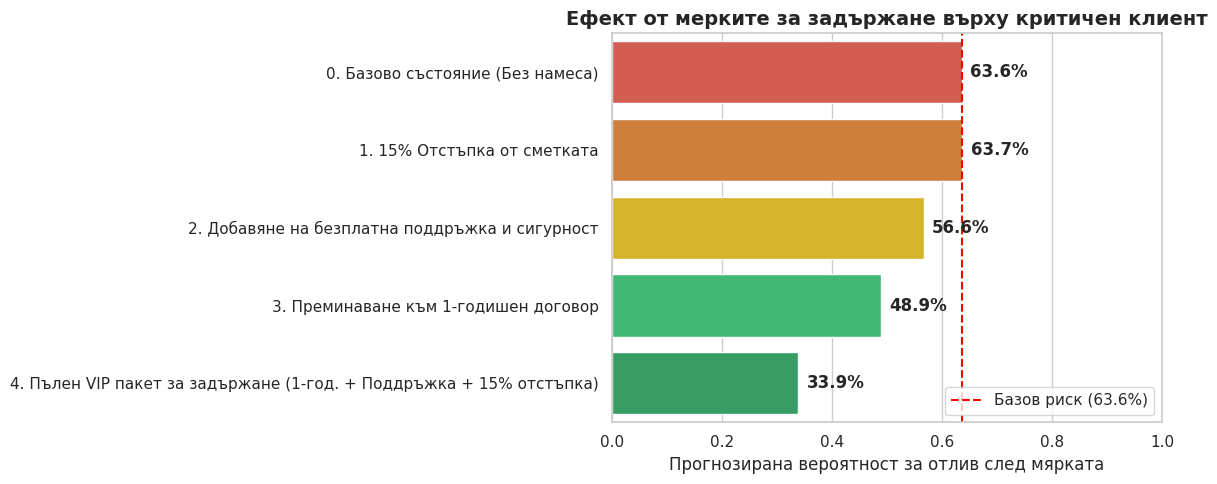

In [6]:
base_profile = personas[1].copy() # Високорисков нов абонат

interventions = [
    ('0. Базово състояние (Без намеса)', base_profile.copy()),
    ('1. 15% Отстъпка от сметката', {**base_profile, 'MonthlyCharges': base_profile['MonthlyCharges'] * 0.85}),
    ('2. Добавяне на безплатна поддръжка и сигурност', {**base_profile, 'TechSupport': 'Yes', 'OnlineSecurity': 'Yes'}),
    ('3. Преминаване към 1-годишен договор', {**base_profile, 'Contract': 'One year'}),
    ('4. Пълен VIP пакет за задържане (1-год. + Поддръжка + 15% отстъпка)', {
        **base_profile, 
        'Contract': 'One year', 
        'TechSupport': 'Yes', 
        'OnlineSecurity': 'Yes',
        'PaymentMethod': 'Bank transfer (automatic)',
        'MonthlyCharges': base_profile['MonthlyCharges'] * 0.85
    })
]

sim_data = [item[1] for item in interventions]
df_policy, _ = predict_customer_churn(sim_data)
df_policy['Политика_за_задържане'] = [item[0] for item in interventions]

base_prob = df_policy.loc[0, 'Вероятност_за_отлив']
df_policy['Намаление_на_риска_%'] = (base_prob - df_policy['Вероятност_за_отлив']) * 100

print('=== РЕЗУЛТАТИ ОТ СИМУЛАЦИЯТА НА МЕРКИ ЗА ЗАДЪРЖАНЕ ===')
print(df_policy[['Политика_за_задържане', 'Вероятност_за_отлив', 'Намаление_на_риска_%', 'Рискова_група']].to_string(index=False))

# Графика на ефективността на мерките
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=df_policy, 
    x='Вероятност_за_отлив', 
    y='Политика_за_задържане', 
    palette=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'],
    ax=ax
)
ax.axvline(base_prob, color='red', linestyle='--', label=f'Базов риск ({base_prob:.1%})')
ax.set_title('Ефект от мерките за задържане върху критичен клиент', fontsize=14, fontweight='bold')
ax.set_xlabel('Прогнозирана вероятност за отлив след мярката', fontsize=12)
ax.set_ylabel('')
for p in ax.patches:
    val = p.get_width()
    ax.annotate(f'{val:.1%}', (val + 0.015, p.get_y() + p.get_height()/2.), va='center', fontweight='bold')
plt.xlim(0, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---## 📊 Пример 5: Пакетна оценка на абонати и изчисляване на застрашения месечен приходЗареждаме извадка от **1000 реални клиентски записа**, изчисляваме застрашения месечен приход ($P(\text{Отлив}) \times \text{Месечна такса}$) и експортираме списък с критичните абонати.

Размер на кохортата: 1,000 клиенти
Общ месечен приход от кохортата:       $64,146.30
Очакван застрашен месечен приход:       $27,842.48 (43.4%)
✅ Експортирани 291 критични абонати във файл: /app/notebooks/telco_high_risk_retention_list.csv


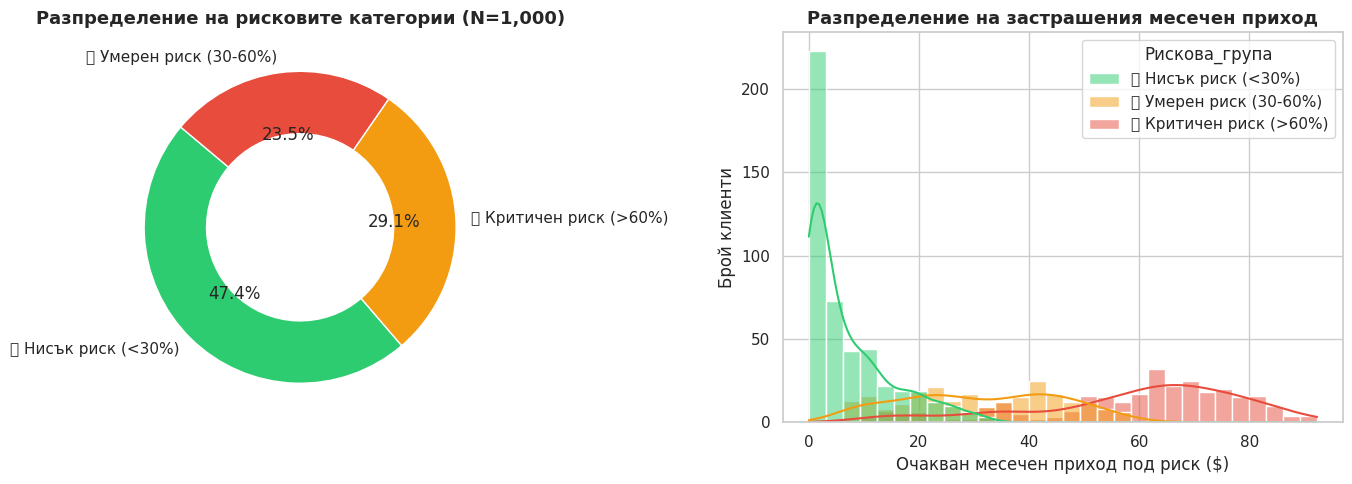

In [7]:
data_csv = '/app/data/churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
if not os.path.exists(data_csv):
    data_csv = './data/churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df_batch_raw = pd.read_csv(data_csv).sample(n=1000, random_state=42)
df_batch_scored, _ = predict_customer_churn(df_batch_raw)

# Изчисляване на застрашения приход
df_batch_scored['Застрашен_месечен_приход'] = df_batch_scored['MonthlyCharges'] * df_batch_scored['Вероятност_за_отлив']
total_monthly_rev = df_batch_scored['MonthlyCharges'].sum()
total_rev_at_risk = df_batch_scored['Застрашен_месечен_приход'].sum()

print(f'Размер на кохортата: {len(df_batch_scored):,} клиенти')
print(f'Общ месечен приход от кохортата:       ${total_monthly_rev:,.2f}')
print(f'Очакван застрашен месечен приход:       ${total_rev_at_risk:,.2f} ({total_rev_at_risk/total_monthly_rev:.1%})')

# Експорт на критичните клиенти за кол-центъра и retention екипа
high_risk_list = df_batch_scored[df_batch_scored['Вероятност_за_отлив'] > 0.60]
export_csv = '/app/notebooks/telco_high_risk_retention_list.csv'
if not os.path.exists('/app/notebooks'):
    export_csv = './notebooks/telco_high_risk_retention_list.csv'
high_risk_list.to_csv(export_csv, index=False)
print(f'✅ Експортирани {len(high_risk_list)} критични абонати във файл: {export_csv}')

# Визуализации
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Кръгова диаграма (Donut chart) на рисковите групи
tier_counts = df_batch_scored['Рискова_група'].value_counts()
ax1.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2ecc71', '#f39c12', '#e74c3c'],
    wedgeprops=dict(width=0.4, edgecolor='w')
)
ax1.set_title('Разпределение на рисковите категории (N=1,000)', fontsize=13, fontweight='bold')

# Хистограма на застрашения месечен приход
sns.histplot(
    data=df_batch_scored, 
    x='Застрашен_месечен_приход', 
    hue='Рискова_група', 
    palette={'🟢 Нисък риск (<30%)': '#2ecc71', '🟡 Умерен риск (30-60%)': '#f39c12', '🔴 Критичен риск (>60%)': '#e74c3c'}, 
    bins=30, 
    kde=True, 
    ax=ax2
)
ax2.set_title('Разпределение на застрашения месечен приход', fontsize=13, fontweight='bold')
ax2.set_xlabel('Очакван месечен приход под риск ($)')
ax2.set_ylabel('Брой клиенти')
plt.tight_layout()
plt.show()

---## 🔍 Пример 6: TreeSHAP анализ на основните фактори за отливИзползваме **TreeSHAP (SHapley Additive exPlanations)** за детайлно разлагане на влиянието на всяка характеристика (вид договор, стаж, оптичен интернет, техническа поддръжка) върху прогнозата.

=== Глобална важност на характеристиките чрез SHAP ===


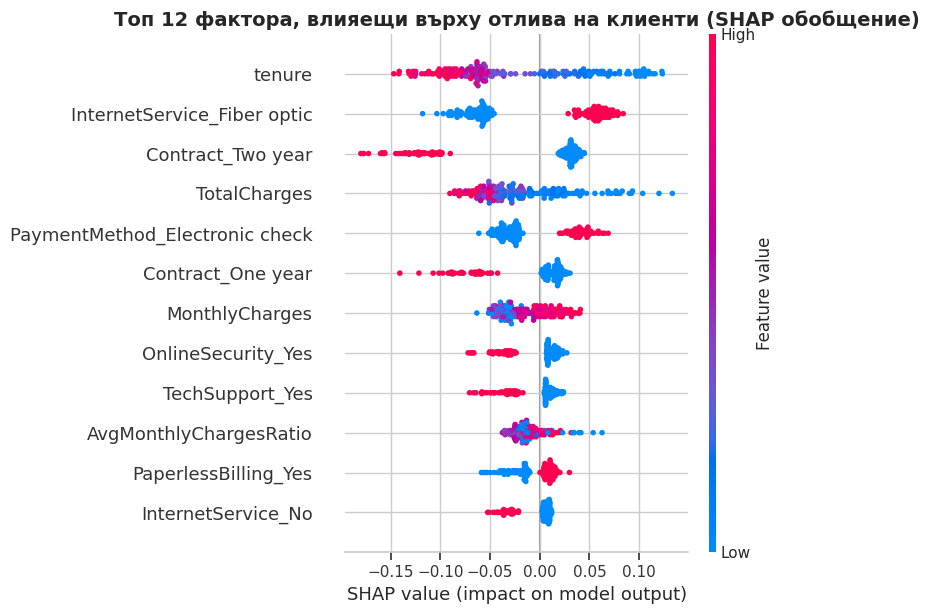

In [8]:
# Изчисляване на SHAP стойности върху представителна извадка
_, X_batch_aligned = predict_customer_churn(df_batch_raw.head(200))
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_batch_aligned)

# Избор на SHAP стойностите за клас 1 (Отлив)
if isinstance(shap_values, list):
    shap_churn = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_churn = shap_values[:, :, 1]
else:
    shap_churn = shap_values

print('=== Глобална важност на характеристиките чрез SHAP ===')
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_churn, X_batch_aligned, max_display=12, show=False)
plt.title('Топ 12 фактора, влияещи върху отлива на клиенти (SHAP обобщение)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---## 🧪 Пример 7: Логване на експеримента и модела в MLflow UIЗаписваме параметрите, метриките и модела в локалния сървър за проследяване на MLflow (**`http://localhost:5000`**).

In [9]:
mlflow_uri = os.environ.get('MLFLOW_TRACKING_URI', 'http://localhost:5000')
if 'mlflow' in os.environ.get('HOSTNAME', '') or os.path.exists('/.dockerenv'):
    mlflow_uri = 'http://mlflow:5000'

mlflow.set_tracking_uri(mlflow_uri)
experiment_name = 'Telco_Customer_Churn_Retention'
mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name='RandomForest_Churn_Classifier_BG_v1') as run:
    # Запис на параметри
    mlflow.log_param('model_type', 'RandomForestClassifier')
    mlflow.log_param('n_estimators', model.n_estimators)
    mlflow.log_param('max_depth', model.max_depth)
    mlflow.log_param('feature_count', len(expected_features))
    
    # Запис на метрики
    mlflow.log_metric('test_accuracy', metrics.get('accuracy', 0.7708))
    mlflow.log_metric('test_roc_auc', metrics.get('roc_auc', 0.8424))
    mlflow.log_metric('batch_revenue_at_risk_usd', total_rev_at_risk)
    
    # Регистриране на модела
    mlflow.sklearn.log_model(model, name='model')
    
    print(f'✅ Успешно записан експеримент в MLflow!')
    print(f'ID на изпълнение (Run ID): {run.info.run_id}')
    print(f'Сървър за проследяване: {mlflow_uri}')
    print(f'Отворете в браузър: http://localhost:5000/#/experiments')

2026/09/08 21:08:07 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.1+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.9.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


✅ Успешно записан експеримент в MLflow!
ID на изпълнение (Run ID): 8e14a1f9b7ae488b83922099dbcacd3f
Сървър за проследяване: http://mlflow:5000
Отворете в браузър: http://localhost:5000/#/experiments
🏃 View run RandomForest_Churn_Classifier_BG_v1 at: http://mlflow:5000/#/experiments/4/runs/8e14a1f9b7ae488b83922099dbcacd3f
🧪 View experiment at: http://mlflow:5000/#/experiments/4
